In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- DADES ---
m1_ = [2, 3, 3, 2, 5]
m2_ = [4, 6, 4, 6, 8]
rr_ = [32, 48, 32, 48, 32]
F0_ = [120, 160, 180, 180, 200]

iopcio = 0

m1 = m1_[iopcio]
m2 = m2_[iopcio]
dr = rr_[iopcio] / 1e3
ds = dr / 2

J2 = round(0.5 * (m2 / 2) * dr**2 * 1e3, 0) / 1e3

F0 = F0_[iopcio]

Xmaxd1 = 14e-3  # m, màxima amplitud de ressonància
f1 = 11.0       # Hz, freqüència de ressonància

t_final = 1.0   # s, temps de simulació

In [2]:
omega1 = f1 * 2 * np.pi # Freqüència angular de ressonància

m_eq = m1 + m2 * (ds/dr)**2 + J2 * (1/dr)**2

A = (2 * omega1**2 * m_eq * Xmaxd1 / F0)**2
a = -(A + 4)
b = (A + 4)
c = -1

zeta_sq_1 = (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)
zeta = np.sqrt(zeta_sq_1)

omegan = omega1 / np.sqrt(1 - 2*zeta**2)
k = omegan**2 * m_eq
c_eq = zeta * 2 * np.sqrt(k * m_eq)

print("\nParàmetres del sistema:")
print("-" * 50)
print(f"Massa:          {m_eq:.3f} kg")
print(f"Rigidesa:       {k:.1f} N/m")
print(f"Esmorteïment:   {c_eq:.2f} Ns/m")
print(f"zeta:           {zeta:.4f}")
print("-" * 50)


Paràmetres del sistema:
--------------------------------------------------
Massa:          3.977 kg
Rigidesa:       20839.9 N/m
Esmorteïment:   121.11 Ns/m
zeta:           0.2104
--------------------------------------------------


In [3]:
# G(s) = 1 / (m s^2 + c s + k)
sys = signal.lti([1.0], [m_eq, c_eq, k])

# --- TEMPS ---
t = np.linspace(0, t_final, 3000)

# --- ENTRADES ---
u_sin = F0 * np.sin(omega1 * t)
u_step = F0 * np.ones_like(t)

# --- SIMULACIONS (lsim per tot) ---
_, x_sin, _  = signal.lsim(sys, U=u_sin, T=t)
_, x_step, _ = signal.lsim(sys, U=u_step, T=t)

# --- VALORS TEÒRICS ---
X  = F0 / np.sqrt((k - m_eq*omega1**2)**2 + (c_eq*omega1)**2)
X0 = F0 / k

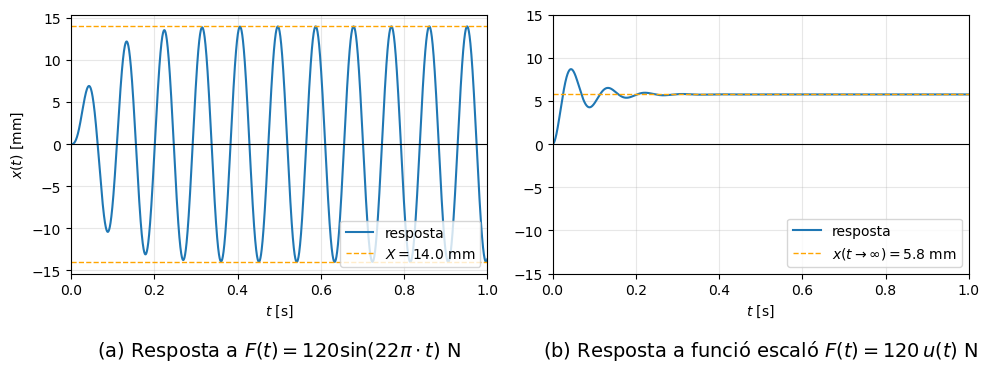

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# --- Ressonància ---
axs[0].plot(t, x_sin*1e3, label=rf"resposta")
axs[0].axhline(X*1e3, color='orange', lw=1, ls='--', label=rf'$X = {X*1e3:.1f}$ mm')
axs[0].axhline(-X*1e3, color='orange', lw=1, ls='--')
axs[0].axhline(0, color='k', lw=0.8,)
axs[0].set_xlabel(r"$t$ [s]")
axs[0].set_ylabel(r"$x(t)$ [mm]")
axs[0].set_xlim(0, t_final)
axs[1].set_ylim(-15, 15)
axs[0].grid(alpha=0.3)
axs[0].legend(loc='lower right')
axs[0].set_title(rf"(a) Resposta a $F(t)={F0}\sin({2*f1:.0f} \pi \cdot t)$ N", y=-0.35, fontsize=14)

# --- Pas ---
axs[1].plot(t, x_step*1e3, label=rf"resposta")
axs[1].axhline(X0*1e3, color='orange', lw=1, ls='--', label=rf'$x(t \rightarrow \infty) = {X0*1e3:.1f}$ mm')
axs[1].axhline(0, color='k', lw=0.8,)
axs[1].set_xlabel(r"$t$ [s]")
axs[1].set_xlim(0, t_final)
axs[1].set_ylim(-15, 15)
axs[1].grid(alpha=0.3)
axs[1].legend(loc='lower right')
axs[1].set_title(rf"(b) Resposta a funció escaló $F(t)={F0}\,u(t)$ N", y=-0.35, fontsize=14)

plt.tight_layout()
plt.show()